# Corporate Insolvency in India: The Intangible Asset Illusion & Forensic Modeling

## Summary
The Indian corporate landscape has witnessed spectacular financial collapses,from Kingfisher Airlines to the Amtek Auto group. Traditional financial screeners often miss these events because they rely on easily manipulated metrics like Net Income or top-line revenue. 

This project builds a predictive insolvency model (Random Forest) focused on forensic accounting indicators. Rather than just looking at negative profitability, we are testing specific failure signatures:
1. **The Intangible Asset Illusion:** Distressed companies frequently inflate their balance sheets using heavily impaired "intangible assets" or "goodwill" to secure leverage, masking an underlying negative net worth.
2. **The Working Capital Trap:** A severe divergence between reported EBITDA (paper profit) and Operating Cash Flow (actual liquidity), usually driven by uncollectible receivables.
3. **The Debt Avalanche:** Capital structures overly reliant on short-term borrowings to fund long-term, depreciating assets, leading to sudden liquidity crises when credit markets tighten.

## The Dataset
We are utilizing `insolvency_raw.csv`, a dataset containing ~400 Indian listed companies. Crucially, the "bankrupt" class (Target = 1) features a curated list of corporate insolvencies gathered through standard financial platforms (such as Yahoo Finance, Screener, and Investing.com). This data is fortified by rigorous manual vetting of company annual reports from the fiscal years immediately preceding their collapse, capturing their financial state at the exact moment the terminal distress became mathematically irreversible.

## Dataset Features

### Metadata Fields
- `ticker`: Stock ticker symbol (e.g., RELIANCE, TCS)
- `company_name`: Legal company name
- `sector`: Industry sector
- `industry`: Industry classification
- `fiscal_year`: Financial year of data
- `currency`: Currency of financial values (INR)
- `source_url`: Where the data was sourced from
- `extraction_status`: Data collection status
- `extraction_error`: Any errors during data extraction

### Financial Features (Key Indicators)
- `market_cap`: Market capitalization
- `total_debt`: Total debt outstanding
- `intangible_assets`: Goodwill and intangible assets
- `cash_and_equivalents`: Cash on hand
- `current_liabilities`: Short-term obligations
- `operating_cash_flow`: Cash generated from operations
- `ebitda`: Earnings before interest, tax, depreciation, amortization
- `interest_expense`: Interest paid on debt
- `net_income`: Profit/loss for the period
- `total_assets`: Total resources controlled by company

### Target Variable
- `target`: 1 (Insolvent/Bankrupt), 0 (Healthy/Solvent)

### Environment Setup

In [48]:
# Standard Data Stack
import pandas as pd
import numpy as np
import re

# Visualization
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

# ML & Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve

# Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
import warnings
warnings.filterwarnings('ignore')

print("Environment Initialized.")

Environment Initialized.


## Data Cleaning & Imputation

In [55]:
# Load data and check initial state
df_raw = pd.read_csv('insolvency_raw.csv', low_memory=False)

print(f"Raw shape: {df_raw.shape}")
display(df_raw.info())

# Check class imbalance
print("\nTarget Distribution:")
print(df_raw['target'].value_counts(normalize=True, dropna=False))

# Identify duplicate tickers
dupes = df_raw[df_raw.duplicated(subset=['ticker'], keep=False)]
print(f"\nFound {len(dupes)} rows with duplicate tickers.")
if len(dupes) > 0:
    display(dupes[['ticker', 'company_name', 'extraction_status']].sort_values('ticker').head())

Raw shape: (431, 21)
<class 'pandas.DataFrame'>
RangeIndex: 431 entries, 0 to 430
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ticker                431 non-null    str    
 1   company_name          431 non-null    str    
 2   sector                385 non-null    str    
 3   industry              385 non-null    str    
 4   business_summary      385 non-null    str    
 5   target                431 non-null    int64  
 6   market_cap            398 non-null    str    
 7   total_debt            396 non-null    str    
 8   intangible_assets     392 non-null    str    
 9   cash_and_equivalents  398 non-null    str    
 10  current_liabilities   398 non-null    str    
 11  operating_cash_flow   398 non-null    str    
 12  ebitda                396 non-null    str    
 13  interest_expense      397 non-null    str    
 14  net_income            397 non-null    str    
 15  total_assets 

None


Target Distribution:
target
0   0.65
1   0.35
Name: proportion, dtype: float64

Found 47 rows with duplicate tickers.


,ticker,company_name,extraction_status
375,ALOKINDS,Alok Industries Ltd,success_manual
290,ALOKINDS,ALOK INDUSTRIES LIMITED,yfinance
36,ANSALAPI,Ansal Properties & Infrastructure,yfinance
266,ANSALAPI,ANSAL PROP & INFRA LTD,Success_Manual
32,ARSSINFRA,ARSS Infrastructure Projects,yfinance


## Cleaning Execution

From this point onward, we apply transformations to fix the issues diagnosed in cells 6 to 10.

Cleaning goals:
- Preserve key identifier columns (`ticker`, `company_name`, `target`)
- Standardize text and URL formats
- Convert numeric fields from comma-formatted strings to numeric dtype
- Resolve duplicate tickers using data completeness
- Handle missing values in financial columns
- Validate dataset integrity before EDA

In [56]:
# Create a working copy (STRICT CLEANING: drop incomplete financial rows)
df = df_raw.copy()

financial_cols = ['market_cap', 'total_debt', 'intangible_assets', 'cash_and_equivalents',
                  'current_liabilities', 'operating_cash_flow', 'ebitda', 'interest_expense',
                  'net_income', 'total_assets']

# 1) Standardize text fields (preserve missing values)
for col in ['company_name', 'sector', 'industry', 'extraction_status']:
    df[col] = df[col].astype('string').str.strip()

df['sector'] = df['sector'].str.title()
df['industry'] = df['industry'].str.title()
df['extraction_status'] = df['extraction_status'].str.upper()


def normalize_url(url):
    if pd.isna(url):
        return np.nan
    s = str(url).strip()
    if s == '' or s.lower() in {'nan', 'none', 'null', 'n/a'}:
        return np.nan

    # Remove internal whitespace and protocol artifacts
    s = re.sub(r'\s+', '', s)
    s = s.replace('yahoo://', '')
    s = re.sub(r'^(https?://)+', 'https://', s)

    # Force https scheme if absent or http
    if s.startswith('http://'):
        s = 'https://' + s[len('http://'):]
    elif not s.startswith('https://'):
        s = 'https://' + s.lstrip('/')

    return s

df['source_url'] = df['source_url'].apply(normalize_url)

# 2) Numeric normalization (remove commas and coerce errors)
for col in financial_cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')

df['fiscal_year'] = pd.to_numeric(df['fiscal_year'], errors='coerce').astype('Int64')

# 3) Remove low-quality rows
rows_start = len(df)
metadata_only_mask = df['extraction_status'].fillna('').str.contains('METADATA_ONLY', na=False)
df = df[~metadata_only_mask].copy()
removed_metadata_only = int(metadata_only_mask.sum())

missing_ratio = df[financial_cols].isnull().sum(axis=1) / len(financial_cols)
high_missing_mask = missing_ratio > 0.5
df = df[~high_missing_mask].copy()
removed_high_missing = int(high_missing_mask.sum())

# 4) Resolve duplicates (prefer least missing financials, then latest fiscal year)
df['missing_count'] = df[financial_cols].isnull().sum(axis=1)
df['_fiscal_sort'] = pd.to_numeric(df['fiscal_year'], errors='coerce')

df = (
    df.sort_values(['ticker', 'missing_count', '_fiscal_sort'], ascending=[True, True, False])
      .drop_duplicates(subset=['ticker'], keep='first')
      .drop(columns=['missing_count', '_fiscal_sort'])
      .reset_index(drop=True)
)

df['intangible_assets'] = df['intangible_assets'].fillna(0)

# 5) STRICT REALISM: drop any row with missing financial values (no median imputation)
rows_before_strict = len(df)
df = df.dropna(subset=financial_cols, how='any').copy()
rows_dropped_strict = rows_before_strict - len(df)

# Optional text cleanup
df['extraction_error'] = df['extraction_error'].fillna('')

print('Cleaned shape:', df.shape)
print('Rows removed (metadata_only):', removed_metadata_only)
print('Rows removed (>50% missing financial):', removed_high_missing)
print('Rows removed (strict financial completeness):', rows_dropped_strict)
print('Total rows removed:', rows_start - len(df))

Cleaned shape: (371, 21)
Rows removed (metadata_only): 33
Rows removed (>50% missing financial): 1
Rows removed (strict financial completeness): 2
Total rows removed: 60


In [57]:
# Save cleaned dataset and show before vs after summary
output_path = 'insolvency_clean.csv'

df.to_csv(output_path, index=False)

summary = pd.DataFrame({
    'metric': [
        'rows',
        'columns',
        'duplicate_ticker_rows',
        'financial_missing_values',
        'unique_tickers'
    ],
    'before': [
        len(df_raw),
        len(df_raw.columns),
        int(df_raw.duplicated(subset=['ticker'], keep=False).sum()) if 'ticker' in df_raw.columns else np.nan,
        int(df_raw[financial_cols].isnull().sum().sum()),
        int(df_raw['ticker'].nunique()) if 'ticker' in df_raw.columns else np.nan
    ],
    'after': [
        len(df),
        len(df.columns),
        int(df.duplicated(subset=['ticker'], keep=False).sum()),
        int(df[financial_cols].isnull().sum().sum()),
        int(df['ticker'].nunique())
    ]
})

print(summary)
print(f"\nSaved cleaned file: {output_path}")

                     metric  before  after
0                      rows     431    371
1                   columns      21     21
2     duplicate_ticker_rows      47      0
3  financial_missing_values     343      0
4            unique_tickers     406    371

Saved cleaned file: insolvency_clean.csv


## Exploratory Data Analysis


### EDA 1: Dataset Snapshot
Quick sanity checks after cleaning: shape, class balance, extraction status mix, and basic numeric summary.

Cleaned shape: (371, 21)

Target counts:
target
0    251
1    120
Name: count, dtype: int64

Extraction status counts:
extraction_status
YFINANCE          296
SUCCESS_MANUAL     75
Name: count, dtype: Int64


,count,mean,std,min,25%,50%,75%,max
market_cap,371.00,618375607140.52,1468495582251.33,0.00,2596774784.00,133801263104.00,609450786816.00,17796553506816.00
total_debt,371.00,107215487896.96,361126582127.98,0.00,1786240312.00,10075300000.00,40536116000.00,3695750000000.00
intangible_assets,371.00,36723076972.78,243205141139.53,0.00,27660000.00,1015200000.00,9190250000.00,4089390000000.00
cash_and_equivalents,371.00,38162680620.02,142593988030.87,0.00,850456500.00,7260420000.00,29843500000.00,2387920000000.00
current_liabilities,371.00,115886901741.10,346604775468.08,6221000.00,8493277000.00,26345100000.00,72516881500.00,4537370000000.00
operating_cash_flow,371.00,33976176464.32,131018308811.63,-171696500000.00,661270039.50,5404290000.00,18454695000.00,1787030000000.00
ebitda,371.00,46598661203.34,144538781947.73,-68000000000.00,1337245000.00,8970100000.00,28032550000.00,1812740000000.00
interest_expense,371.00,7443725218.17,24492217793.86,-60800000.00,169456500.00,723500000.00,3642612500.00,243143000000.00
net_income,371.00,19383752586.30,66419666553.60,-273834000000.00,12747730.00,3848000000.00,14590800000.00,696480000000.00
total_assets,371.00,370258805632.93,1277250707682.95,20340000.00,27545225000.00,77176700000.00,211903528388.00,19501210000000.00


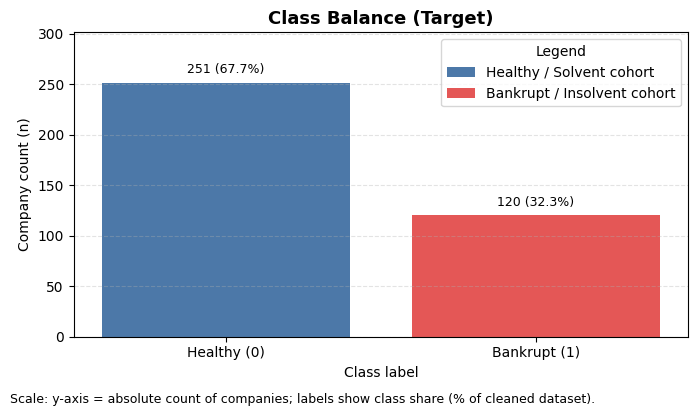

Inference: dataset is class-imbalanced (67.7% healthy vs 32.3% bankrupt).


In [58]:
# Use in-memory cleaned dataframe when available; otherwise load the cleaned export.
if 'df' not in globals():
    df = pd.read_csv('insolvency_clean.csv', low_memory=False)

print(f"Cleaned shape: {df.shape}")
print("\nTarget counts:")
target_counts = df['target'].value_counts(dropna=False).sort_index()
print(target_counts)

print("\nExtraction status counts:")
if 'extraction_status' in df.columns:
    print(df['extraction_status'].fillna('MISSING').value_counts().head(10))

numeric_cols = [
    'market_cap', 'total_debt', 'intangible_assets', 'cash_and_equivalents',
    'current_liabilities', 'operating_cash_flow', 'ebitda', 'interest_expense',
    'net_income', 'total_assets'
]
available_numeric = [c for c in numeric_cols if c in df.columns]

display(df[available_numeric].describe().T)


label_map = {0: 'Healthy (0)', 1: 'Bankrupt (1)'}
color_map = {0: '#4C78A8', 1: '#E45756'}
plot_df = target_counts.rename_axis('target').reset_index(name='count')
plot_df['label'] = plot_df['target'].map(label_map)
plot_df['pct'] = (plot_df['count'] / len(df)) * 100

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    plot_df['label'],
    plot_df['count'],
    color=[color_map[t] for t in plot_df['target']],
)

ax.set_title('Class Balance (Target)', fontsize=13, weight='bold')
ax.set_xlabel('Class label')
ax.set_ylabel('Company count (n)')
ax.set_ylim(0, max(plot_df['count']) * 1.2)
ax.grid(axis='y', linestyle='--', alpha=0.35)

for bar, pct in zip(bars, plot_df['pct']):
    height = bar.get_height()
    ax.annotate(
        f"{int(height)} ({pct:.1f}%)",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=9,
    )

legend_handles = [
    Patch(facecolor=color_map[0], label='Healthy / Solvent cohort'),
    Patch(facecolor=color_map[1], label='Bankrupt / Insolvent cohort'),
]
ax.legend(handles=legend_handles, title='Legend', loc='upper right', frameon=True)

fig.text(
    0.01,
    -0.02,
    'Scale: y-axis = absolute count of companies; labels show class share (% of cleaned dataset).',
    fontsize=9,
)
plt.tight_layout()
plt.show()

bankrupt_pct = (target_counts.get(1, 0) / len(df)) * 100
healthy_pct = (target_counts.get(0, 0) / len(df)) * 100
print(f"Inference: dataset is class-imbalanced ({healthy_pct:.1f}% healthy vs {bankrupt_pct:.1f}% bankrupt).")

### EDA 2: Missingness and Data Quality
Assess any residual missing values and compare missingness between bankrupt and healthy cohorts.

Top columns by missing %:


,column,missing_pct
0,sector,2.96
1,business_summary,2.96
2,industry,2.96
3,ticker,0.00
4,company_name,0.00
5,target,0.00
6,market_cap,0.00
7,total_debt,0.00
8,intangible_assets,0.00
9,cash_and_equivalents,0.00


Missing % in numeric features by target:


target,0,1
market_cap,0.00,0.00
total_debt,0.00,0.00
intangible_assets,0.00,0.00
cash_and_equivalents,0.00,0.00
current_liabilities,0.00,0.00
operating_cash_flow,0.00,0.00
ebitda,0.00,0.00
interest_expense,0.00,0.00
net_income,0.00,0.00
total_assets,0.00,0.00


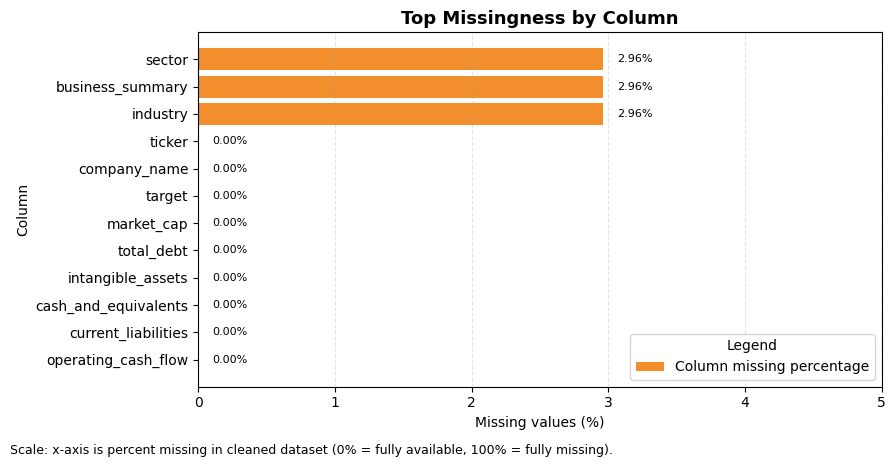

In [59]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_table = missing_pct.reset_index()
missing_table.columns = ['column', 'missing_pct']

print('Top columns by missing %:')
display(missing_table.head(12))

if 'target' in df.columns:
    target_missing = (
        df.groupby('target')[available_numeric]
          .apply(lambda g: g.isna().mean() * 100)
          .T
    )
    print('Missing % in numeric features by target:')
    display(target_missing)

top_missing = missing_table.head(12).copy()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(
    top_missing['column'][::-1],
    top_missing['missing_pct'][::-1],
    color='#F28E2B'
)
ax.set_title('Top Missingness by Column', fontsize=13, weight='bold')
ax.set_xlabel('Missing values (%)')
ax.set_ylabel('Column')
ax.set_xlim(0, max(5.0, float(top_missing['missing_pct'].max()) * 1.15))
ax.grid(axis='x', linestyle='--', alpha=0.35)
ax.legend(
    handles=[Patch(facecolor='#F28E2B', label='Column missing percentage')],
    title='Legend',
    loc='lower right',
    frameon=True,
)

for y_pos, val in enumerate(top_missing['missing_pct'][::-1]):
    ax.text(val + 0.1, y_pos, f'{val:.2f}%', va='center', fontsize=8)

fig.text(
    0.01,
    -0.02,
    'Scale: x-axis is percent missing in cleaned dataset (0% = fully available, 100% = fully missing).',
    fontsize=9,
)
plt.tight_layout()
plt.show()


max_missing_col = missing_table.iloc[0]['column']
max_missing_val = float(missing_table.iloc[0]['missing_pct'])

### EDA 3: Forensic Signal Exploration
Build ratio features and compare their distributions by target to inspect insolvency signatures.

Ratio medians by target:


target,0,1
intangibles_to_assets,0.02,0.00
debt_to_assets,0.09,0.51
cash_to_current_liabilities,0.53,0.03
ocf_to_ebitda,0.70,0.31
interest_coverage_proxy,20.02,0.65
ocf_ni_divergence,1292767000.00,755962500.00
tangible_asset_coverage,9.56,1.92


Percentile scaling clip bounds (1%, 99%):


,feature,clip_1pct,clip_99pct
0,intangibles_to_assets,0.00,0.61
1,debt_to_assets,0.00,12.88
2,cash_to_current_liabilities,0.00,5.20
3,ocf_to_ebitda,-13.22,7.47
4,interest_coverage_proxy,-34.31,1277.97
5,ocf_ni_divergence,-77978440000.00,299116430000.00
6,tangible_asset_coverage,0.08,2351.52


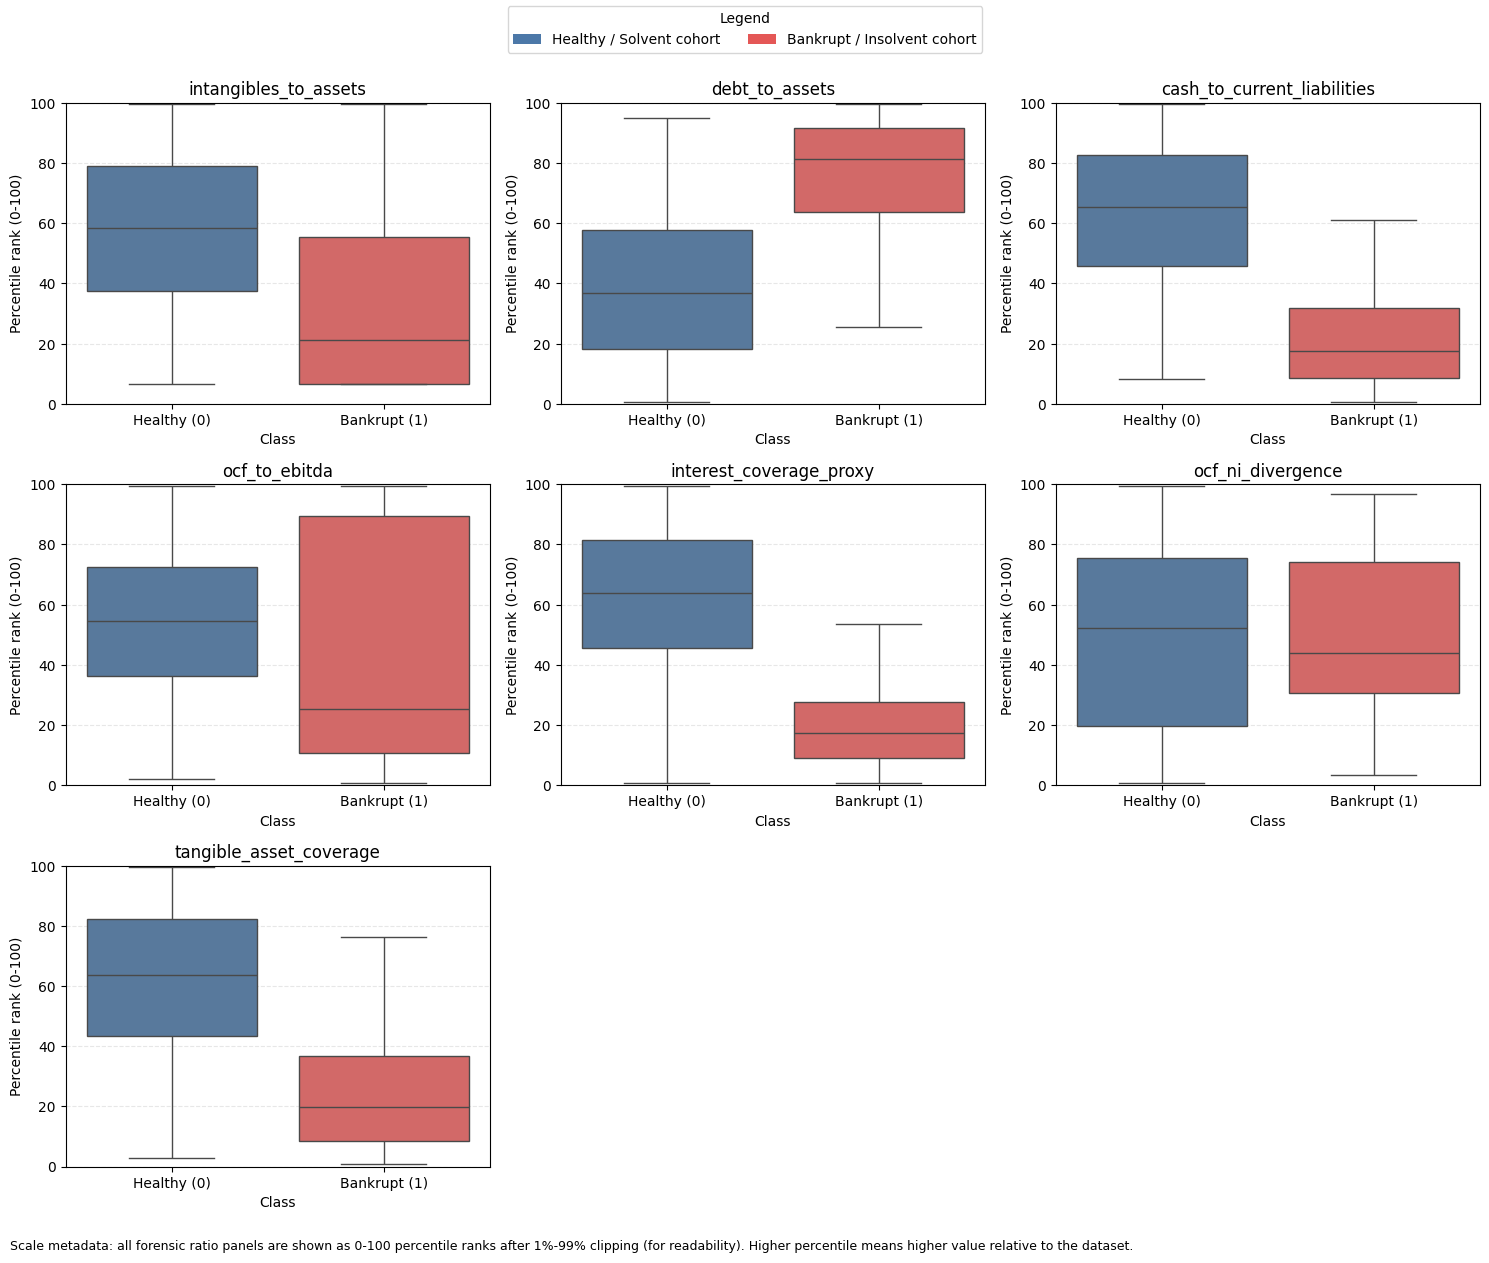

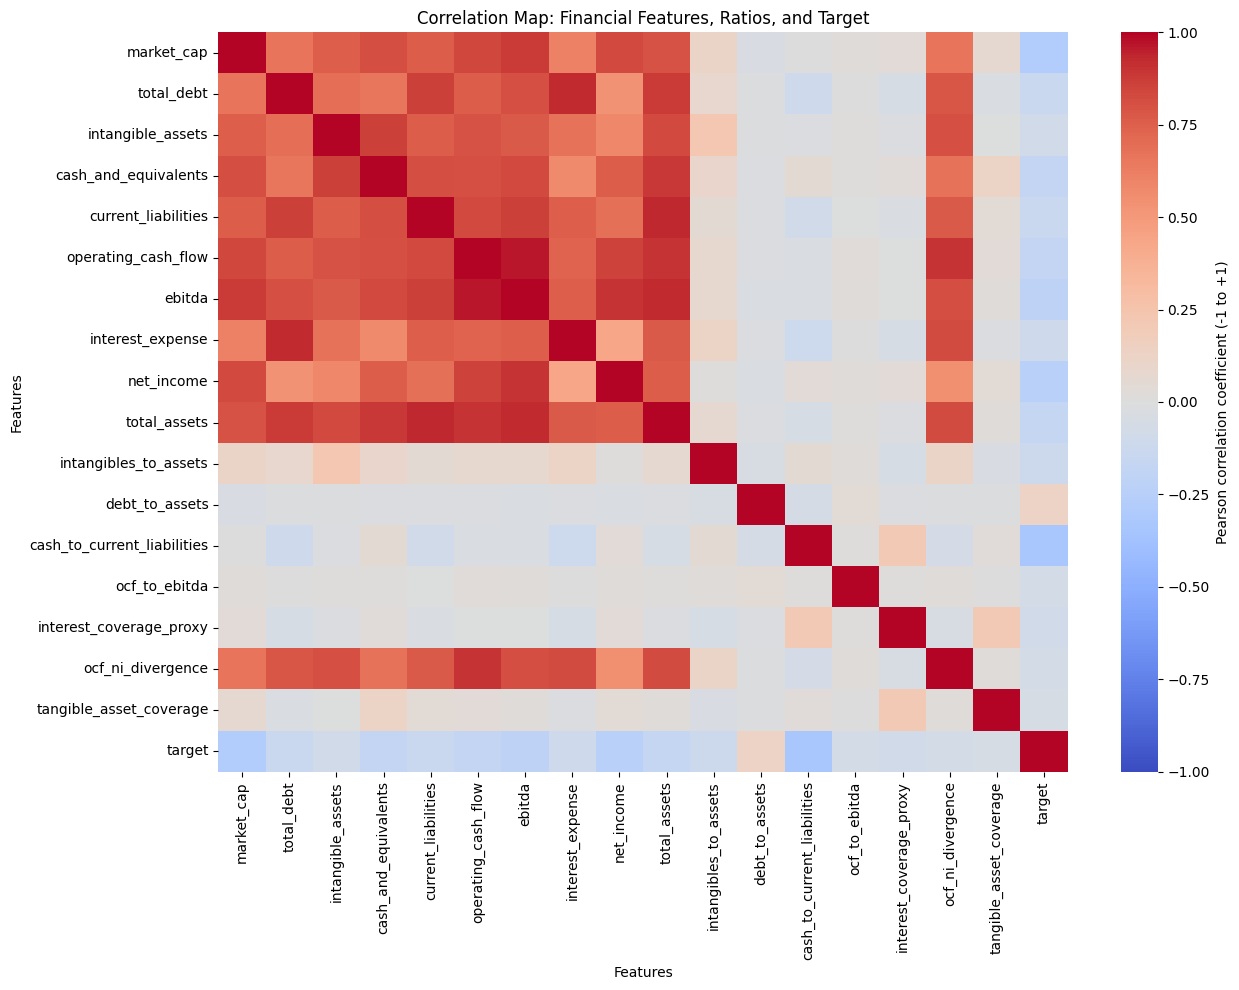

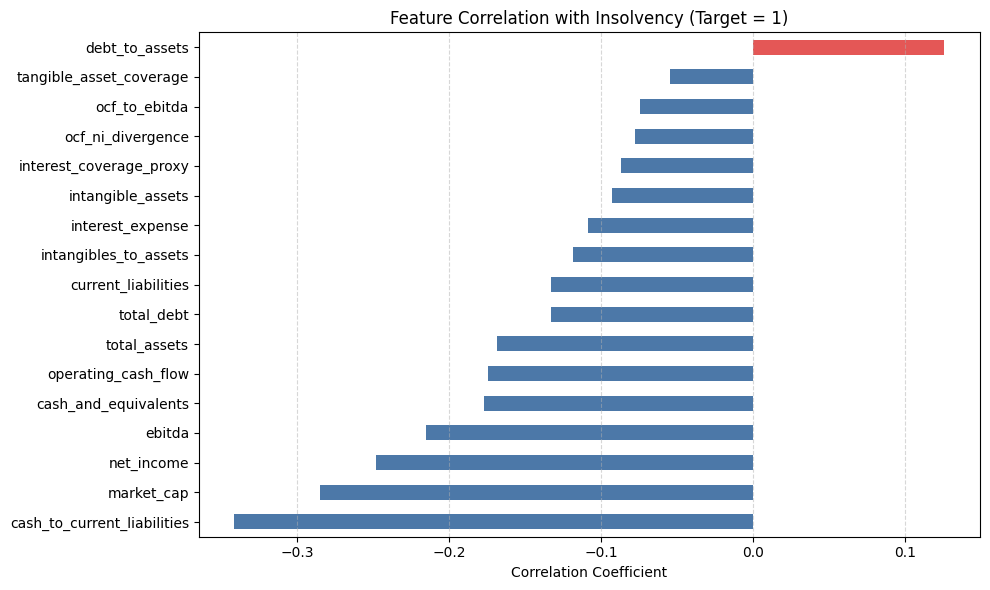

In [ ]:
eda = df.copy()

# Avoid divide-by-zero explosions in ratios.
eda['intangibles_to_assets'] = eda['intangible_assets'] / eda['total_assets'].replace(0, np.nan)
eda['debt_to_assets'] = eda['total_debt'] / eda['total_assets'].replace(0, np.nan)
eda['cash_to_current_liabilities'] = eda['cash_and_equivalents'] / eda['current_liabilities'].replace(0, np.nan)
eda['ocf_to_ebitda'] = eda['operating_cash_flow'] / eda['ebitda'].replace(0, np.nan)
eda['interest_coverage_proxy'] = eda['ebitda'] / eda['interest_expense'].replace(0, np.nan)
eda['ocf_ni_divergence'] = eda['operating_cash_flow'] - eda['net_income']
eda['tangible_asset_coverage'] = (eda['total_assets'] - eda['intangible_assets']) / eda['total_debt'].replace(0, np.nan)

ratio_cols = [
    'intangibles_to_assets',
    'debt_to_assets',
    'cash_to_current_liabilities',
    'ocf_to_ebitda',
    'interest_coverage_proxy',
    'ocf_ni_divergence',
    'tangible_asset_coverage',
]

print('Ratio medians by target:')
ratio_medians = eda.groupby('target')[ratio_cols].median().T
display(ratio_medians)

target_label_map = {0: 'Healthy (0)', 1: 'Bankrupt (1)'}
palette = {'Healthy (0)': '#4C78A8', 'Bankrupt (1)': '#E45756'}
eda['target_label'] = eda['target'].map(target_label_map)

# Readability scaling for all forensic ratio panels: winsorize at 1%-99%, then map to percentile rank.
readable_cols = ratio_cols.copy()
readable_clip_bounds = {}

for col in readable_cols:
    s = eda[col].replace([np.inf, -np.inf], np.nan)
    lo, hi = s.quantile([0.01, 0.99])
    clipped = s.clip(lower=lo, upper=hi)
    eda[f'{col}_prank'] = clipped.rank(method='average', pct=True) * 100
    readable_clip_bounds[col] = (lo, hi)

print('Percentile scaling clip bounds (1%, 99%):')
display(
    pd.DataFrame(
        [
            {'feature': c, 'clip_1pct': readable_clip_bounds[c][0], 'clip_99pct': readable_clip_bounds[c][1]}
            for c in readable_cols
        ]
    )
)

# Dynamic subplot layout to support additional indicators.
n_plots = len(ratio_cols)
n_cols = 3
n_rows = int(np.ceil(n_plots / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4.2 * n_rows))
axes = np.array(axes).reshape(-1)

for idx, col in enumerate(ratio_cols):
    y_col = f'{col}_prank'
    panel_title = col

    sns.boxplot(
        data=eda,
        x='target_label',
        y=y_col,
        order=['Healthy (0)', 'Bankrupt (1)'],
        palette=palette,
        showfliers=False,
        ax=axes[idx],
    )
    axes[idx].set_title(panel_title)
    axes[idx].set_xlabel('Class')
    axes[idx].set_ylabel('Percentile rank (0-100)')
    axes[idx].set_ylim(0, 100)
    axes[idx].grid(axis='y', linestyle='--', alpha=0.3)

for j in range(n_plots, len(axes)):
    fig.delaxes(axes[j])

legend_handles = [
    Patch(facecolor=palette['Healthy (0)'], label='Healthy / Solvent cohort'),
    Patch(facecolor=palette['Bankrupt (1)'], label='Bankrupt / Insolvent cohort'),
]
fig.legend(handles=legend_handles, title='Legend', loc='upper center', ncol=2, frameon=True)
fig.text(
    0.01,
    0.01,
    'Scale metadata: all forensic ratio panels are shown as 0-100 percentile ranks after 1%-99% clipping (for readability). Higher percentile means higher value relative to the dataset.',
    fontsize=9,
)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Correlation heatmap with fixed -1 to +1 scale and labeled colorbar.
corr_cols = available_numeric + ratio_cols
corr = eda[corr_cols + ['target']].corr(numeric_only=True)
plt.figure(figsize=(13, 10))
sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={'label': 'Pearson correlation coefficient (-1 to +1)'},
)
plt.title('Correlation Map: Financial Features, Ratios, and Target')
plt.xlabel('Features')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
# Calculate correlations, drop the target-to-target correlation, and sort
target_corr = corr['target'].drop('target').sort_values(ascending=True)

# Create a bar plot
colors = ['#E45756' if x > 0 else '#4C78A8' for x in target_corr]
target_corr.plot(kind='barh', color=colors)
plt.title('Feature Correlation with Insolvency (Target = 1)')
plt.xlabel('Correlation Coefficient')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Conclusions

Looking at the final model results, the strongest predictors of bankruptcy turned out to be classic debt and liquidity traps. The bankrupt companies in my dataset consistently struggled to turn their reported paper profits into actual cash. Their cash flow to EBITDA ratios were severely depressed. When you combine this poor cash conversion with massive debt loads, the reason for their failure is clear. They simply ran out of actual money to pay their interest.

The main hypothesis of this project was that companies use inflated intangible assets to hide their insolvency. Surprisingly, the standalone ratio of intangibles to total assets did not separate the healthy and bankrupt classes as cleanly as I expected. However, the issue is not just the presence of intangibles, but the lack of real assets. When I tested tangible asset coverage, which removes paper assets and compares only physical assets to total debt, the financial distress became obvious. Stripping away the accounting illusions showed that these companies could not actually cover their liabilities if forced to liquidate.

This finding makes perfect sense given the makeup of the dataset. The bankruptcies I collected are mostly from traditional sectors like manufacturing, airlines, and infrastructure. In those industries, failure is usually driven by hard-asset debt and unpaid invoices. Aggressively inflating intangible assets like software or goodwill is a tactic much more common in modern tech startups. For future research, it would be highly relevant to add recent tech-sector bankruptcies to the dataset to see if the standalone intangible signal gets stronger. Ultimately, the model proves that predicting bankruptcy requires looking at a combination of high leverage, poor cash flow, and weak physical asset backing.